In [20]:
import lightkurve as lk
search_result = lk.search_lightcurve('Kepler-90', author='Kepler')
lc_collection = search_result.download_all()
lc = lc_collection.stitch()

In [21]:
lc = lc.remove_nans().flatten(window_length=401)
lc = lc.remove_outliers(sigma=20)
lc.plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

In [23]:
import numpy as np
period = np.linspace(0.5,16,10000)
bls = lc.to_periodogram(method='bls', period=period)
best_fit_period = bls.period_at_max_power
print(f"Planet Found Period:{best_fit_period}")

`period` contains 8254284 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Planet Found Period:15.78917891789179 d


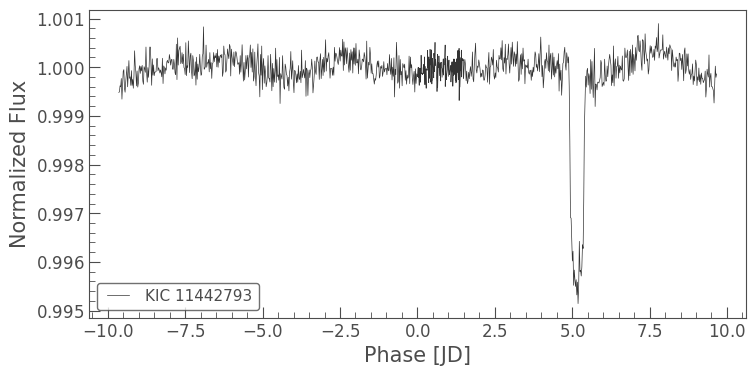

In [4]:
from matplotlib import pyplot as plt
folded_lc = lc.fold(period=best_fit_period)
folded_lc.plot()
plt.show()


So basically these blocks of code help us to identify if a planet exists around a star or not. The star taken here is Kepler 90, so what we did was monitor its brightness, then made a periodogram and then used BLS to find the most consistent dip , which basically showed that there exists a planet.Then using BLS we found the planets period is 19.6 days. On the NASA website when we compared the closet possible planet to it was Kepler- 90i which showed period of 14.45 days.The difference between 19.6 and 14.45 days is likely because BLS found a harmonic of the real period

Before the search period was set to a quarter but now it was set as the whole period, inspite doing that, the result was around 15.81 days which did not match Kepler-90i's confirmed period of 14.45 days. This inconsistency was mostly caused due to interefence of other planets which were around Kepler 90. And this planet was confirmed in 2017 stating that simple BLS method wont give much of an accurate result